In [18]:
# Cell 1: imports & setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)


In [19]:
df = pd.read_csv("./Housing.csv")
print(df.shape)
df.head(3)
# Quick: dtypes per column
df.dtypes
# Rich summary: types + non-null counts + memory
df.info()
# Nice table: dtype + percent missing + number of unique values
# pd.DataFrame({
#     "dtype": df.dtypes.astype(str),
#     "null_%": df.isna().mean().round(3),
#     "n_unique": df.nunique()
# }).sort_index()



(21613, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64

In [20]:
# Parse date and cast identifiers to string
df["date"] = pd.to_datetime(df["date"], format="%Y%m%dT%H%M%S", errors="coerce")
df["id"] = df["id"].astype("string")
df["zipcode"] = df["zipcode"].astype("string")

# Recheck
df.dtypes



id               string[python]
date             datetime64[ns]
price                   float64
bedrooms                  int64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
zipcode          string[python]
lat                     float64
long                    float64
sqft_living15             int64
sqft_lot15                int64
dtype: object

In [21]:
# How many exact duplicate rows?
exact_dupes = df.duplicated().sum()

# Same id repeated (likely multiple sales over time)
dupe_ids = df.duplicated(subset=["id"]).sum()

# Same id + same date repeated (true duplicates of a transaction)
dupe_id_date = df.duplicated(subset=["id","date"]).sum()

print(f"Exact duplicate rows: {exact_dupes}")
print(f"Rows with duplicated id: {dupe_ids}")
print(f"Rows with duplicated (id, date): {dupe_id_date}")

# Peek at a repeated id
rep = df[df["id"].duplicated(keep=False)].sort_values(["id","date"]).head(6)
rep[["id","date","price","sqft_living","zipcode"]]


Exact duplicate rows: 0
Rows with duplicated id: 177
Rows with duplicated (id, date): 0


,id,date,price,sqft_living,zipcode
2496,1000102,2014-09-16,280000.0,2400,98002
2497,1000102,2015-04-22,300000.0,2400,98002
12065,1036400200,2015-02-13,661000.0,1670,98052
12066,1036400200,2015-04-29,697000.0,1670,98052
11433,109200390,2014-08-20,245000.0,1480,98023
11434,109200390,2014-10-20,250000.0,1480,98023


In [22]:
# Cell 2: choose 1 feature and clean
FEATURE = "sqft_living"   # <- change me to e.g. "bedrooms", "bathrooms", etc.
TARGET  = "price"

# Keep only rows where feature and target are valid numbers
keep = df[TARGET].notna() & df[FEATURE].notna() & (df[TARGET] > 0)
data = df.loc[keep, [FEATURE, TARGET]].copy()

print(data.describe().T)
print("\nRows kept:", len(data))


               count           mean            std      min       25%  \
sqft_living  21613.0    2079.899736     918.440897    290.0    1427.0   
price        21613.0  540088.576690  367126.825086  75000.0  321950.0   

                  50%       75%        max  
sqft_living    1910.0    2550.0    13540.0  
price        450000.0  645000.0  7700000.0  

Rows kept: 21613


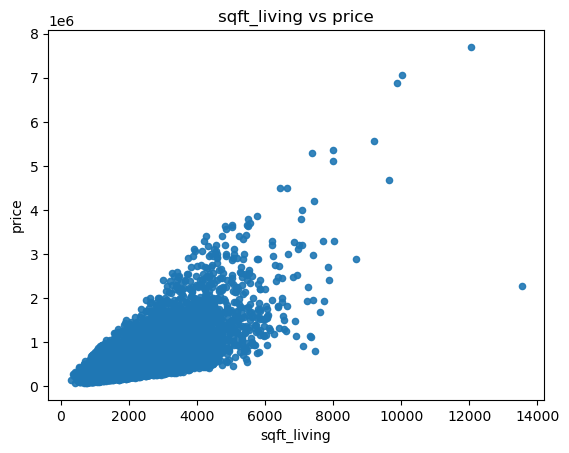

Pearson correlation(sqft_living, price): 0.702


In [31]:
# Cell 3: visualize feature vs price
ax = data.plot.scatter(x=FEATURE, y=TARGET, alpha=0.9)
ax.set_title(f"{FEATURE} vs {TARGET}")
plt.show()

corr = data[[FEATURE, TARGET]].corr().iloc[0,1]
print(f"Pearson correlation({FEATURE}, {TARGET}): {corr:.3f}")



In [32]:
# Cell 4: split + metrics helper
X = data[[FEATURE]].values   # 2D for sklearn
y = data[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

def evaluate(name, model, X_train, y_train, X_test, y_test, plot_line=True):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    print(f"{name:>18} | RMSE: {rmse:,.0f} | R²: {r2:.3f}")

    # Optional: draw regression line on top of scatter
    if plot_line:
        # scatter training data (light) + test (darker)
        plt.scatter(X_train[:,0], y_train, alpha=0.15, label="train")
        plt.scatter(X_test[:,0],  y_test,  alpha=0.6,  label="test")
        xs = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
        ys = model.predict(xs)
        plt.plot(xs, ys, linewidth=2, label=name)
        plt.xlabel(FEATURE); plt.ylabel(TARGET); plt.legend(); plt.title("Fit line")
        plt.show()

    return rmse, r2


  LinearRegression | RMSE: 276,559 | R²: 0.494


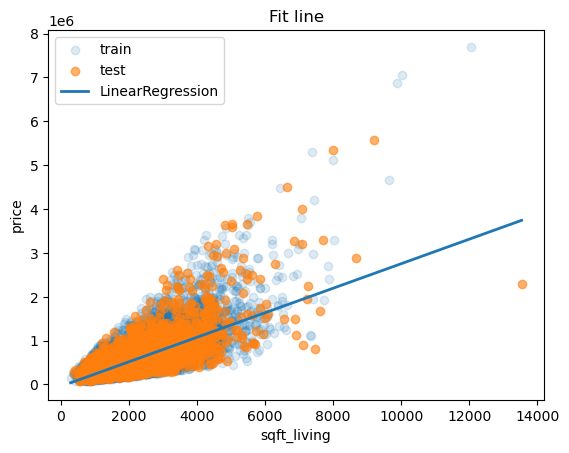

Slope (Δprice/Δsqft_living): 279.55
Intercept: -41,997.42


In [33]:
# Cell 6: simple linear regression with imputation (just in case)
linreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   LinearRegression())
])

evaluate("LinearRegression", linreg, X_train, y_train, X_test, y_test, plot_line=True)

# Inspect learned parameters (slope b and intercept a)
m = linreg.named_steps["model"].coef_[0]
b = linreg.named_steps["model"].intercept_
print(f"Slope (Δ{TARGET}/Δ{FEATURE}): {m:,.2f}")
print(f"Intercept: {b:,.2f}")


  Log-Price Linear | RMSE: 726,737 | R²: -2.494


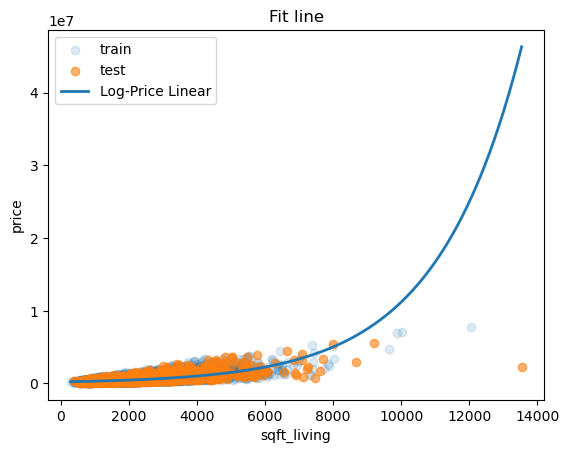

(np.float64(726737.3682603982), -2.4935751316558714)

In [26]:
# Cell 7: log-transform the target to reduce skew: model price ~ linear in feature
log_linreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("ttr", TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p, inverse_func=np.expm1
    ))
])

evaluate("Log-Price Linear", log_linreg, X_train, y_train, X_test, y_test, plot_line=True)


In [27]:
# Cell 8: cross-validation scores (R² and RMSE)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores  = cross_val_score(linreg, X, y, cv=cv, scoring="r2")
rmse_scores = -cross_val_score(linreg, X, y, cv=cv, scoring="neg_root_mean_squared_error")

print("CV R²  :", np.round(r2_scores, 3), "→ mean:", r2_scores.mean().round(3))
print("CV RMSE:", np.round(rmse_scores, 0), "→ mean:", np.mean(rmse_scores).round(0))


CV R²  : [0.494 0.496 0.486 0.501 0.482] → mean: 0.492
CV RMSE: [276559. 272816. 255729. 255842. 245634.] → mean: 261316.0


In [28]:
# Cell 9: predict price for a specific feature value
your_value = 1800  # e.g., 1800 sqft living area
pred_price = linreg.predict(np.array([[your_value]]))[0]
pred_price_log = log_linreg.predict(np.array([[your_value]]))[0]

print(f"Pred (Linear) for {FEATURE}={your_value}: {pred_price:,.0f}")
print(f"Pred (Log-Price) for {FEATURE}={your_value}: {pred_price_log:,.0f}")


Pred (Linear) for sqft_living=1800: 461,200
Pred (Log-Price) for sqft_living=1800: 414,634


In [29]:
# Cell 10: Gradient Descent demo for 1 feature

x = X_train[:,0].astype(float)
y_true = y_train.astype(float)

# Normalize x and y for stable learning
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y_true.mean(), y_true.std()
x_n = (x - x_mean) / x_std
y_n = (y_true - y_mean) / y_std

# Model: y_n_hat = a + b * x_n
a, b = 0.0, 0.0
lr = 0.1
epochs = 2000

for _ in range(epochs):
    y_hat = a + b * x_n
    err = y_hat - y_n
    # gradients (MSE)
    da = 2 * err.mean()
    db = 2 * (err * x_n).mean()
    a -= lr * da
    b -= lr * db

# Convert back to original scale:
# y = y_mean + y_std*(a + b * (x - x_mean)/x_std) = (y_mean + y_std*a - y_std*b*x_mean/x_std) + (y_std*b/x_std) * x
intercept_gd = y_mean + y_std*a - (y_std*b*x_mean)/x_std
slope_gd     = (y_std*b)/x_std

print(f"GD slope ≈ {slope_gd:,.2f}, intercept ≈ {intercept_gd:,.2f}")

# Compare to sklearn's closed-form solution:
m = linreg.named_steps["model"].coef_[0]
b0 = linreg.named_steps["model"].intercept_
print(f"SK slope ≈ {m:,.2f}, intercept ≈ {b0:,.2f}")


GD slope ≈ 279.55, intercept ≈ -41,997.42
SK slope ≈ 279.55, intercept ≈ -41,997.42


PyTorch: 2.5.1 | device: cuda
slope_gd = 279.55 | intercept_gd = -41,997.31
sklearn slope = 279.55 | intercept = -41,997.42
GD (GPU) | RMSE: 276,559 | R²: 0.494


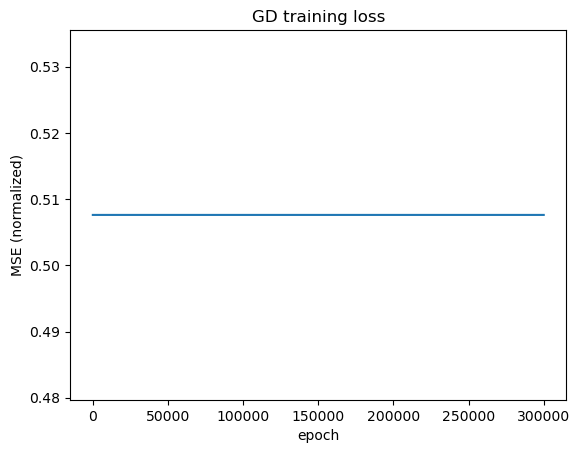

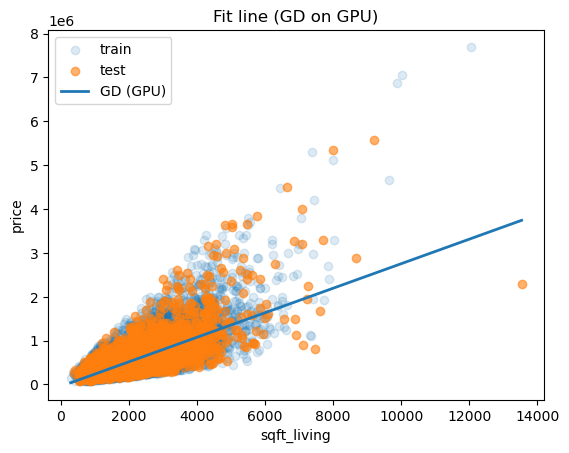

In [35]:
# Cell 10 — Gradient Descent on GPU (PyTorch)
# If you get "ModuleNotFoundError: No module named 'torch'", install PyTorch first.

import torch, numpy as np, matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

# --- Take the training split created earlier (X_train, y_train) and move to torch ---
x = torch.tensor(X_train[:, 0], dtype=torch.float32, device=device)
y = torch.tensor(y_train,       dtype=torch.float32, device=device)

# --- Normalize for stable learning (z-score, use population std to match numpy's default) ---
x_mean, x_std = x.mean(), x.std(unbiased=False)
y_mean, y_std = y.mean(), y.std(unbiased=False)
x_n = (x - x_mean) / x_std
y_n = (y - y_mean) / y_std

# --- Model in normalized space: y_hat = a + b*x ---
a = torch.nn.Parameter(torch.tensor(0.0, device=device))
b = torch.nn.Parameter(torch.tensor(0.0, device=device))

# Full-batch GD (SGD with batch=all). For tiny data, GPU won't be faster—but it's the same code path.
lr = 0.1
epochs = 300000
opt = torch.optim.SGD([a, b], lr=lr)

loss_hist = []
for epoch in range(epochs):
    opt.zero_grad()
    y_hat = a + b * x_n
    loss = torch.mean((y_hat - y_n) ** 2)  # MSE in normalized units
    loss.backward()
    opt.step()
    if (epoch + 1) % 100 == 0:
        loss_hist.append(loss.item())

# --- Convert learned params back to original scale ---
# y = y_mean + y_std*(a + b*(x - x_mean)/x_std) = (y_mean + y_std*a - y_std*b*x_mean/x_std) + (y_std*b/x_std)*x
intercept_gd = (y_mean + y_std * a - (y_std * b * x_mean) / x_std).detach().cpu().item()
slope_gd     = (y_std * b / x_std).detach().cpu().item()
print(f"slope_gd = {slope_gd:,.2f} | intercept_gd = {intercept_gd:,.2f}")

# --- Compare to sklearn (if you ran Cell 6) ---
try:
    m = linreg.named_steps["model"].coef_[0]
    b0 = linreg.named_steps["model"].intercept_
    print(f"sklearn slope = {m:,.2f} | intercept = {b0:,.2f}")
except Exception:
    pass

# --- Evaluate on test split (same metrics as before) ---
x_te = torch.tensor(X_test[:, 0], dtype=torch.float32, device=device)
y_te = torch.tensor(y_test,       dtype=torch.float32, device=device)
y_pred_te = intercept_gd + slope_gd * x_te

rmse_te = torch.sqrt(torch.mean((y_te - y_pred_te) ** 2)).item()
ss_res = torch.sum((y_te - y_pred_te) ** 2).item()
ss_tot = torch.sum((y_te - y_te.mean()) ** 2).item()
r2_te = 1.0 - ss_res / ss_tot
print(f"GD (GPU) | RMSE: {rmse_te:,.0f} | R²: {r2_te:.3f}")

# --- Plots ---
# 1) training loss (normalized MSE)
plt.plot(np.arange(len(loss_hist)) * 100 + 100, loss_hist)
plt.xlabel("epoch"); plt.ylabel("MSE (normalized)"); plt.title("GD training loss"); plt.show()

# 2) fitted line vs data
plt.scatter(X_train[:, 0], y_train, alpha=0.15, label="train")
plt.scatter(X_test[:, 0],  y_test,  alpha=0.6,  label="test")
xs = np.linspace(X.min(), X.max(), 200)
ys = intercept_gd + slope_gd * xs
plt.plot(xs, ys, linewidth=2, label="GD (GPU)")
plt.xlabel(FEATURE); plt.ylabel(TARGET); plt.legend(); plt.title("Fit line (GD on GPU)"); plt.show()


In [36]:
# Cell A — Compare RMSE (abs error) vs RMSLE (relative error)
import numpy as np

# Fallback RMSLE if sklearn's mean_squared_log_error isn't available
def _rmsle(y_true, y_pred):
    y_true = np.maximum(y_true, 1)   # guard against log of <=0
    y_pred = np.maximum(y_pred, 1)
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))

# Get predictions on the same test set
pred_lin = linreg.predict(X_test)
pred_log = log_linreg.predict(X_test)

rmse_lin = np.sqrt(np.mean((y_test - pred_lin)**2))
rmse_log = np.sqrt(np.mean((y_test - pred_log)**2))

rmsle_lin = _rmsle(y_test, pred_lin)
rmsle_log = _rmsle(y_test, pred_log)

print(f"Linear:   RMSE = {rmse_lin:,.0f}  |  RMSLE = {rmsle_lin:.4f}")
print(f"Log-Price:RMSE = {rmse_log:,.0f}  |  RMSLE = {rmsle_log:.4f}")


Linear:   RMSE = 276,559  |  RMSLE = 0.4083
Log-Price:RMSE = 726,737  |  RMSLE = 0.3819


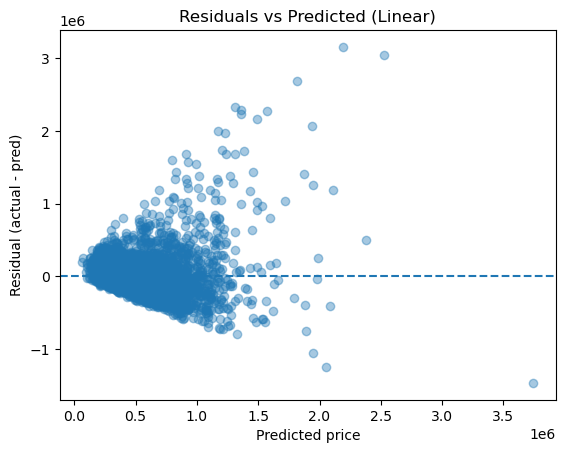

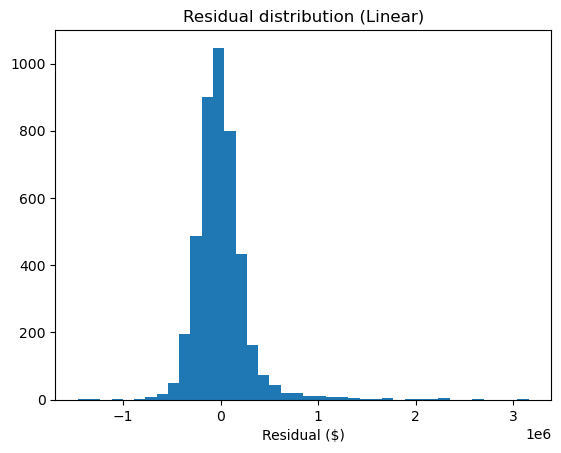

In [37]:
# Cell B — Residual plots for the linear model
import matplotlib.pyplot as plt
resid = y_test - pred_lin

plt.scatter(pred_lin, resid, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price"); plt.ylabel("Residual (actual - pred)")
plt.title("Residuals vs Predicted (Linear)"); plt.show()

plt.hist(resid, bins=40)
plt.title("Residual distribution (Linear)"); plt.xlabel("Residual ($)")
plt.show()


In [38]:
# Optional Cell — One feature + its square
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

poly2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),  # [x, x^2]
    ("model", LinearRegression())
])

poly2.fit(X_train, y_train)
pred_poly2 = poly2.predict(X_test)

rmse_poly2 = np.sqrt(np.mean((y_test - pred_poly2)**2))
r2_poly2   = r2_score(y_test, pred_poly2)
print(f"Poly2 (x + x²) | RMSE: {rmse_poly2:,.0f} | R²: {r2_poly2:.3f}")


Poly2 (x + x²) | RMSE: 286,555 | R²: 0.457
